<a href="https://colab.research.google.com/github/Symphoen1x/projectTA/blob/main/Salinan_dari_Versi_Dataset_Lokal_dari_Smart_Attandance_System_DIGIBIN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* note: nanti akhir pakai: by Face Detection + ID Match Pipeline

# Smart Attandance System for DIGIBIN MOBILE FEATURE

## Import Library

In [ ]:
import os
import cv2
import glob as gb
import kagglehub
import math
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
gpu_device = tf.config.experimental.list_physical_devices('GPU')
print(f"Number of GPU = {len(gpu_device)}")

if gpu_device:
    tf.config.experimental.set_memory_growth(gpu_device[0], True)
    print("GPU memory growth enabled.")
else:
    print("No GPU devices found. Running on CPU.")

Number of GPU = 1
GPU memory growth enabled.


## Import Data

In [ ]:
!pip install -q split-folders
%pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.2 MB/s eta 0:00:00


In [ ]:
import os
import shutil

output_dir = 'local_data'
zip_path = '/content/datasetLokalNew.zip'

# Bersihkan folder jika ada sisa ekstraksi gagal
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
os.makedirs(output_dir, exist_ok=True)

if os.path.exists(zip_path):
    print(f"Mengecek integritas {zip_path}...")
    # Tes apakah zip valid
    test_zip = !unzip -t {zip_path}

    if any("End-of-central-directory signature not found" in line for line in test_zip):
        print("\n[ERROR] FILE ZIP RUSAK (INCOMPLETE UPLOAD)")
        print("------------------------------------------")
        print("Penyebab: File belum selesai diunggah atau terputus.")
        print("Solusi:")
        print("1. Klik kanan 'datasetLokalNew.zip' di folder kiri -> Delete file.")
        print("2. Unggah ulang file tersebut.")
        print("3. TUNGGU sampai lingkaran progres kecil di bawah nama file selesai.")
        print("4. Jalankan ulang sel ini.")
    else:
        !unzip -q {zip_path} -d {output_dir}
        print(f"Berhasil: Data diekstrak ke {output_dir}/")
else:
    print(f"Error: File '{zip_path}' tidak ditemukan di folder /content/")

Mengecek integritas /content/datasetLokalNew.zip...
Berhasil: Data diekstrak ke local_data/


In [ ]:
# List the contents of the output directory to identify the extracted image directory
extracted_contents = os.listdir(output_dir)

# Initialize images_path to output_dir as a default or fallback
images_path = output_dir

# Assuming there's typically one main folder inside the zip after extraction
# Or if the images are directly in output_dir, then output_dir itself is the path
if extracted_contents:
    # Heuristic: if there's only one directory, assume it's the image root
    if len(extracted_contents) == 1 and os.path.isdir(os.path.join(output_dir, extracted_contents[0])):
        images_path = os.path.join(output_dir, extracted_contents[0])
    # No 'else' needed here, as images_path is already initialized to output_dir
    print(f"The directory containing the extracted images is likely: {images_path}")
    print("Contents of the extracted directory (first 5 items):")
    for item in os.listdir(images_path)[:5]:
        print(f"- {item}")
else:
    print(f"No contents found in {output_dir}. Please verify the zip file structure.")
    # images_path remains output_dir as initialized

local_data_path = images_path # Storing the path for subsequent steps

The directory containing the extracted images is likely: local_data/datasetLokalNew
Contents of the extracted directory (first 5 items):
- Bruno
- Weslley
- Juliana
- Daiane
- Matheus


## Data Splitting

In [ ]:
import splitfolders
import os # Ensure os is imported

SEED = 100
IMG_SIZE = 228
BATCH_SIZE = 75
output_split_dir = 'output'
os.makedirs(output_split_dir, exist_ok=True)

# Check if local_data_path is empty before attempting to split
if not os.path.exists(local_data_path) or not os.listdir(local_data_path):
    print(f"Error: The input directory for splitting, '{local_data_path}', is empty or does not exist.")
    print("Please ensure your dataset is correctly extracted in the previous steps.")
    raise ValueError(f"Input directory '{local_data_path}' is empty. Data extraction might have failed.")

splitfolders.ratio(local_data_path, output=output_split_dir, seed=SEED, ratio=(.7, .2, .1), group_prefix=None)

TRAIN_DIR = os.path.join(output_split_dir, 'train')
VALID_DIR = os.path.join(output_split_dir, 'val')
TEST_DIR = os.path.join(output_split_dir, 'test')

print(f"Data split into train, validation, and test directories under: {output_split_dir}/")
print(f"Train directory: {TRAIN_DIR}")
print(f"Validation directory: {VALID_DIR}")
print(f"Test directory: {TEST_DIR}")

Copying files: 206 files [00:00, 361.65 files/s]

Data split into train, validation, and test directories under: output/
Train directory: output/train
Validation directory: output/val
Test directory: output/test


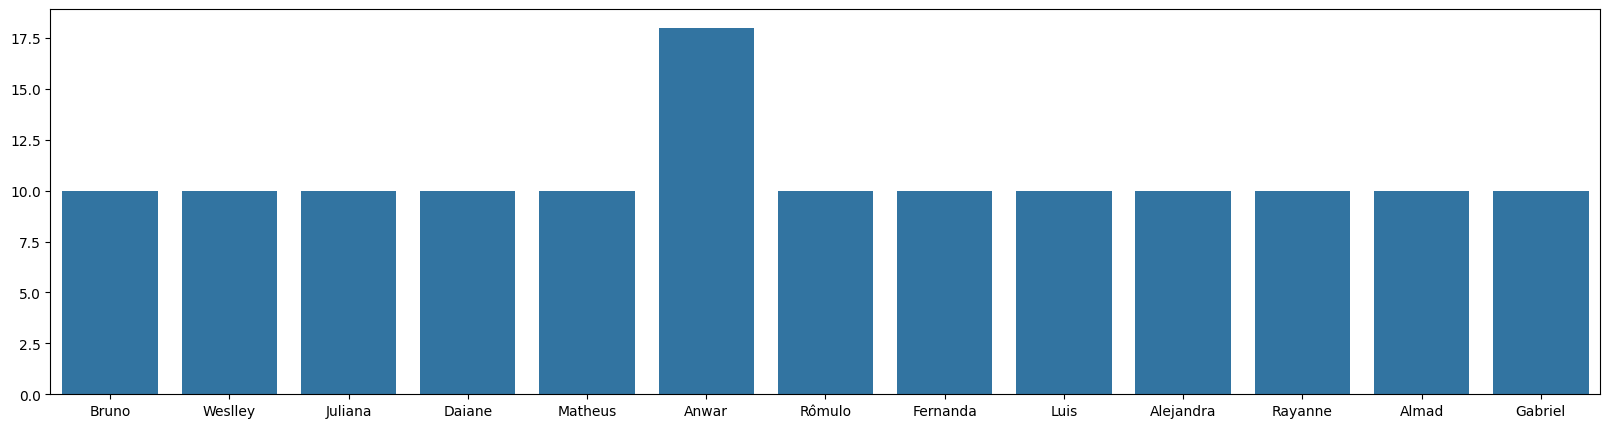

In [ ]:
class_names = []
class_count = []
train_examples = 0
for f in os.listdir(TRAIN_DIR):
    files = gb.glob(pathname=str(TRAIN_DIR + "/" + f + "/*"))
    class_names.append(f)
    class_count.append(len(files))
    train_examples += len(files)
plt.figure(figsize=(20,5))
sns.barplot(x=class_names, y=class_count)
plt.show()

In [ ]:
def display_sample_filenames(directory, split_name, num_samples_per_class=2):
    print(f"\n--- Sample files from {split_name} directory ---")
    class_dirs = [d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d))]
    for class_name in class_dirs:
        class_path = os.path.join(directory, class_name)
        image_files = gb.glob(os.path.join(class_path, '*')) # Get all files in the class directory
        if image_files:
            print(f"Class: {class_name}")
            for i, file_path in enumerate(image_files[:num_samples_per_class]):
                print(f"  - {os.path.basename(file_path)}")

# Display samples for TRAIN_DIR
display_sample_filenames(TRAIN_DIR, 'TRAIN')

# Display samples for VALID_DIR
display_sample_filenames(VALID_DIR, 'VALIDATION')

# Display samples for TEST_DIR
display_sample_filenames(TEST_DIR, 'TEST')



--- Sample files from TRAIN directory ---
Class: Bruno
  - Selfie_12.jpg
  - Selfie_10.jpg
Class: Weslley
  - Selfie_12.jpg
  - Selfie_10.jpg
Class: Juliana
  - Selfie_12.jpg
  - Selfie_10.jpg
Class: Daiane
  - Selfie_12.jpg
  - Selfie_10.jpg
Class: Matheus
  - Selfie_12.jpg
  - Selfie_10.jpg
Class: Anwar
  - 0.jpg
  - 18.jpg
Class: Rômulo
  - Selfie_12.jpg
  - Selfie_10.jpg
Class: Fernanda
  - Selfie_12.jpg
  - Selfie_10.jpg
Class: Luis
  - Selfie_12.jpg
  - Selfie_10.jpg
Class: Alejandra
  - Selfie_12.jpg
  - Selfie_10.jpg
Class: Rayanne
  - Selfie_12.jpg
  - Selfie_10.jpg
Class: Almad
  - Selfie_13.jpg
  - Selfie_12.jpg
Class: Gabriel
  - Selfie_12.jpg
  - Selfie_10.jpg

--- Sample files from VALIDATION directory ---
Class: Bruno
  - Selfie_13.jpg
  - Selfie_9.jpg
Class: Weslley
  - Selfie_13.jpg
  - Selfie_9.jpg
Class: Juliana
  - Selfie_13.jpg
  - Selfie_9.jpg
Class: Daiane
  - Selfie_13.jpg
  - Selfie_9.jpg
Class: Matheus
  - Selfie_13.jpg
  - Selfie_9.jpg
Class: Anwar
  - 23.j

In [ ]:
# train_gen = ImageDataGenerator(
#     rotation_range=25,
#     width_shift_range=0.1,
#     height_shift_range=0.1,
#     zoom_range = 0.2,
#     horizontal_flip=True,
#     preprocessing_function=tf.keras.applications.vgg19.preprocess_input,
#     dtype='float32'
# )

In [ ]:
train_gen = ImageDataGenerator(
    rotation_range=40, # Increased from 25 to 40
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range = 0.3, # Increased from 0.2 to 0.3
    brightness_range=(0.8, 1.2), # Added brightness range
    horizontal_flip=True,
    preprocessing_function=tf.keras.applications.vgg19.preprocess_input,
    dtype='float32'
)


In [ ]:
train_batch = train_gen.flow_from_directory(
    directory=TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode = 'sparse',
    seed=SEED
)

Found 138 images belonging to 13 classes.


In [ ]:
valid_batch = train_gen.flow_from_directory(
    directory=VALID_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode = 'sparse',
    seed=SEED
)

Found 41 images belonging to 13 classes.


## Pra-processing Data


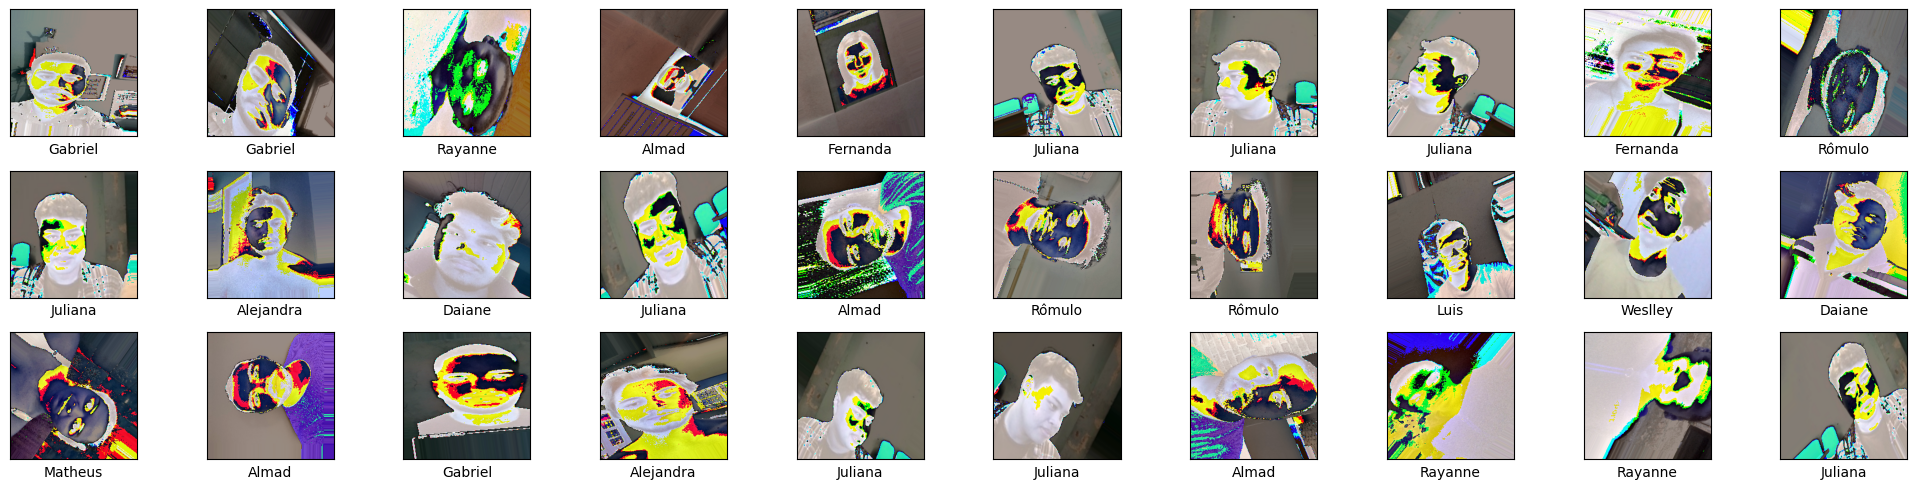

In [ ]:
imgs, labels = next(train_batch)
i=0
plt.figure(figsize=(20,5))
for img,label in zip(imgs,labels):
  plt.subplot(3,10,i+1)
  plt.imshow(img.astype('uint8'))
  plt.xlabel(class_names[label.astype('int32')])
  plt.xticks([])
  plt.yticks([])
  i+=1
  if i==30:
    break
plt.tight_layout()
plt.show()

In [ ]:
# IMG_SHAPE = (IMG_SIZE,IMG_SIZE) + (3,)
# base_model = tf.keras.applications.VGG19(input_shape=IMG_SHAPE,
#                                                include_top=False,
#                                                weights='imagenet')

## Training Model

In [ ]:
# 1. DEFINISI ARSITEKTUR MODEL
IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)
base_model = tf.keras.applications.VGG19(input_shape=IMG_SHAPE,
                                         include_top=False,
                                         weights='imagenet')
base_model.trainable = False  # Freeze base model terlebih dahulu

inputs = tf.keras.Input(shape=IMG_SHAPE)
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(512, activation='relu')(x)
x = tf.keras.layers.Dense(512, activation='relu')(x)
x = tf.keras.layers.Dropout(0.1)(x)
outputs = tf.keras.layers.Dense(len(class_names), activation='softmax')(x)
model = tf.keras.Model(inputs, outputs)

# 2. KOMPILASI MODEL
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 3. CUSTOM CALLBACK (PENGHENTIAN OTOMATIS)
class CustomStopper(tf.keras.callbacks.Callback):
    def __init__(self, acc_threshold=0.95, val_acc_threshold=0.95):
        super(CustomStopper, self).__init__()
        self.acc_threshold = acc_threshold
        self.val_acc_threshold = val_acc_threshold

    def on_epoch_end(self, epoch, logs=None):
        acc = logs.get('accuracy')
        val_acc = logs.get('val_accuracy')
        if acc >= self.acc_threshold and val_acc >= self.val_acc_threshold:
            print(f"\nEpoch {epoch+1}: Target akurasi {self.acc_threshold} tercapai. Berhenti!")
            self.model.stop_training = True

custom_stopper = CustomStopper(acc_threshold=0.95, val_acc_threshold=0.95)

# 4. TRAINING MODEL
print("Memulai Training...")
history = model.fit(
    train_batch,
    epochs=50,
    validation_data=valid_batch,
    callbacks=[custom_stopper]
)

model.summary()

Memulai Training...
Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 79s 44s/step - accuracy: 0.0652 - loss: 4.1447 - val_accuracy: 0.2683 - val_loss: 2.8616
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 16s 10s/step - accuracy: 0.3696 - loss: 2.5273 - val_accuracy: 0.4634 - val_loss: 1.9871
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 10s/step - accuracy: 0.5507 - loss: 1.7976 - val_accuracy: 0.7317 - val_loss: 1.2736
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 10s/step - accuracy: 0.7464 - loss: 1.0619 - val_accuracy: 0.8293 - val_loss: 0.7363
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 8s/step - accuracy: 0.7609 - loss: 0.7564 - val_accuracy: 0.7317 - val_loss: 0.7483
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 8s/step - accuracy: 0.8623 - loss: 0.5067 - val_accuracy: 0.7317 - val_loss: 0.6613
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 8s/step - accuracy: 0.8551 - loss: 0.4483 - val_accuracy: 0.7561 - val_loss: 0.4677
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 7s/step - accuracy: 0.8768 - loss: 0.3363 - val_accuracy: 0.9268 - v

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 228, 228, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 13)             │         6,669 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,620,329 (82.48 MB)

 Trainable params: 531,981 (2.03 MB)

 Non-trainable params: 20,024,384 (76.39 MB)

 Optimizer params: 1,063,964 (4.06 MB)

### Fine-Tuning Model
Untuk meningkatkan akurasi pada data baru, kita akan membuka (unfreeze) beberapa layer terakhir dari VGG19 agar model bisa menyesuaikan fitur visualnya dengan dataset spesifik Anda.

In [ ]:
# --- STEP 1: FINE-TUNING ---
# Unfreeze 4 layer terakhir dari base_model
base_model.trainable = True
for layer in base_model.layers[:-4]:
    layer.trainable = False

# Compile ulang dengan learning rate yang lebih rendah (1e-5)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Memulai Fine-tuning...")
h_fine = model.fit(
    train_batch,
    epochs=10,
    validation_data=valid_batch,
    callbacks=[custom_stopper]
)

print("Fine-tuning selesai.")
# Langkah selanjutnya: Jalankan cell Vn7MpYVRQZoU untuk visualisasi atau uNfeeimMAJCB untuk tes upload foto.

Memulai Fine-tuning...
Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 29s 12s/step - accuracy: 0.9928 - loss: 0.0425 - val_accuracy: 0.9268 - val_loss: 0.1796
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9964 - loss: 0.0266
Epoch 2: Target akurasi 0.95 tercapai. Berhenti!
2/2 ━━━━━━━━━━━━━━━━━━━━ 16s 9s/step - accuracy: 0.9928 - loss: 0.0351 - val_accuracy: 0.9756 - val_loss: 0.1601
Fine-tuning selesai.


In [ ]:
class CustomStopper(tf.keras.callbacks.Callback):
    def __init__(self, acc_threshold=0.95, val_acc_threshold=0.95, loss_threshold=0.2, val_loss_threshold=0.2):
        super(CustomStopper, self).__init__()
        self.acc_threshold = acc_threshold
        self.val_acc_threshold = val_acc_threshold
        self.loss_threshold = loss_threshold
        self.val_loss_threshold = val_loss_threshold

    def on_epoch_end(self, epoch, logs=None):
        current_acc = logs.get('accuracy')
        current_val_acc = logs.get('val_accuracy')
        current_loss = logs.get('loss')
        current_val_loss = logs.get('val_loss')

        if (current_acc is not None and current_acc >= self.acc_threshold and
            current_val_acc is not None and current_val_acc >= self.val_acc_threshold and
            current_loss is not None and current_loss <= self.loss_threshold and
            current_val_loss is not None and current_val_loss <= self.val_loss_threshold):
            print(f"\nEpoch {epoch+1}: All custom stopping conditions met. Stopping training.")
            self.model.stop_training = True

# Instantiate the custom callback with desired thresholds
custom_stopper = CustomStopper(acc_threshold=0.95, val_acc_threshold=0.95, loss_threshold=0.2, val_loss_threshold=0.2)

h = model.fit(train_batch,
              epochs=50,
              steps_per_epoch = math.ceil(120 / BATCH_SIZE),
              validation_data = valid_batch,
              validation_steps = math.ceil(36 / BATCH_SIZE),
              callbacks=[custom_stopper] # Use the custom callback
             )

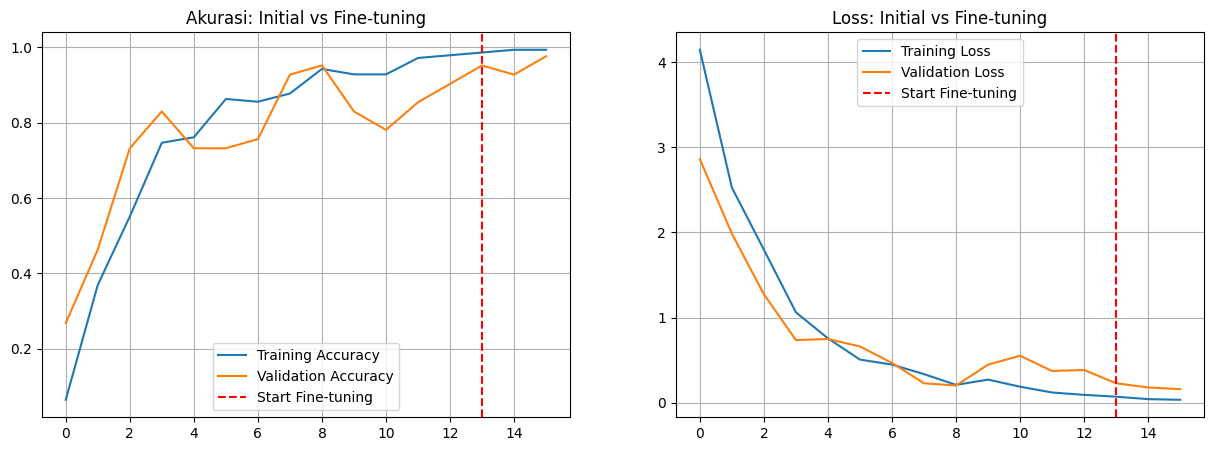

In [ ]:
# --- STEP 2: VISUALISASI HASIL ---
plt.figure(figsize=(15,5))

# Menggabungkan history training awal dan fine-tuning
acc = history.history['accuracy'] + h_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + h_fine.history['val_accuracy']
loss = history.history['loss'] + h_fine.history['loss']
val_loss = history.history['val_loss'] + h_fine.history['val_loss']

# Plot Akurasi
plt.subplot(1,2,1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.axvline(len(history.history['accuracy'])-1, color='r', linestyle='--', label='Start Fine-tuning')
plt.title('Akurasi: Initial vs Fine-tuning')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1,2,2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.axvline(len(history.history['loss'])-1, color='r', linestyle='--', label='Start Fine-tuning')
plt.title('Loss: Initial vs Fine-tuning')
plt.legend()
plt.grid(True)

plt.show()

## Evaluation Model

In [ ]:
# --- STEP 3: EVALUASI PADA DATA TEST ---
test_gen = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg19.preprocess_input)
test_batch = test_gen.flow_from_directory(
    directory=TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

loss_t, acc_t = model.evaluate(test_batch)
print(f"\nAkurasi pada Data Test: {acc_t*100:.2f}%")

Found 27 images belonging to 13 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.9259 - loss: 0.2617

Akurasi pada Data Test: 92.59%


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 987ms/step

Classification Report:
              precision    recall  f1-score   support

   Alejandra       1.00      1.00      1.00         2
       Almad       1.00      1.00      1.00         2
       Anwar       1.00      1.00      1.00         3
       Bruno       1.00      1.00      1.00         2
      Daiane       1.00      1.00      1.00         2
    Fernanda       1.00      1.00      1.00         2
     Gabriel       1.00      0.50      0.67         2
     Juliana       1.00      1.00      1.00         2
        Luis       1.00      1.00      1.00         2
     Matheus       1.00      1.00      1.00         2
     Rayanne       0.50      1.00      0.67         2
     Rômulo       1.00      0.50      0.67         2
     Weslley       1.00      1.00      1.00         2

    accuracy                           0.93        27
   macro avg       0.96      0.92      0.92        27
weighted avg       0.96      0.93      0.93        27



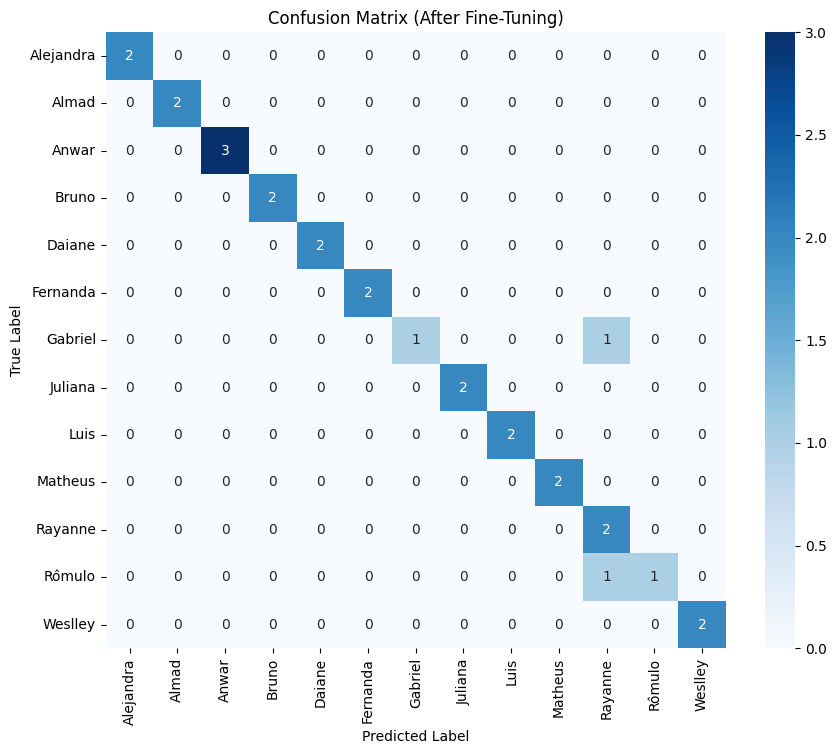

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Get true labels and predictions for the test set
y_true = []
y_pred = []

# Reset the test_batch generator to ensure we go through all samples
test_batch.reset()

# Iterate through the test_batch to collect true labels and predictions
for i in range(len(test_batch)):
    images, labels = test_batch[i]
    predictions = model.predict(images)
    predicted_classes = np.argmax(predictions, axis=1)
    y_true.extend(labels)
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Get class names in the order they were processed by the ImageDataGenerator
class_labels = list(test_batch.class_indices.keys())

# Generate Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Generate Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (After Fine-Tuning)')
plt.show()

## Feature Upload Foto for Real-time Prediction



In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output, Image as DisplayImage
from PIL import Image
import numpy as np
import tensorflow as tf
import os

# 1. Pastikan class_labels tersedia
try:
    class_labels = list(test_batch.class_indices.keys())
except NameError:
    print("Error: test_batch tidak ditemukan. Pastikan sel evaluasi sudah dijalankan.")

# 2. Fungsi Prediksi
def do_prediction(btn):
    with output_area:
        clear_output()
        if not upload_widget.value:
            print("Silakan pilih file terlebih dahulu!")
            return

        # Ambil data file
        file_info = list(upload_widget.value.values())[0]
        content = file_info['content']

        # Simpan sementara
        with open("temp_test.jpg", "wb") as f:
            f.write(content)

        # Tampilkan Gambar
        display(DisplayImage("temp_test.jpg", width=250))

        # Preprocessing & Predict
        img = Image.open("temp_test.jpg").convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        img_array = np.array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = tf.keras.applications.vgg19.preprocess_input(img_array)

        preds = model.predict(img_array)
        idx = np.argmax(preds)
        conf = np.max(preds) * 100

        print(f"\n--- HASIL ---")
        print(f"Identitas: {class_labels[idx]}")
        print(f"Confidence: {conf:.2f}%")

# 3. Buat UI Sederhana
upload_widget = widgets.FileUpload(accept='.jpg,.jpeg,.png', multiple=False)
predict_button = widgets.Button(description="Cek Foto Sekarang", button_style='success')
output_area = widgets.Output()

predict_button.on_click(do_prediction)

print("LANGKAH:")
print("1. Klik 'Upload' untuk memilih foto.")
print("2. Klik 'Cek Foto Sekarang' untuk melihat hasil.")
display(upload_widget, predict_button, output_area)

LANGKAH:
1. Klik 'Upload' untuk memilih foto.
2. Klik 'Cek Foto Sekarang' untuk melihat hasil.


FileUpload(value={}, accept='.jpg,.jpeg,.png', description='Upload')

Button(button_style='success', description='Cek Foto Sekarang', style=ButtonStyle())

Output()